# MNIST ANN training

Notebook này minh họa nhanh luồng train của tab Predict bằng thư mục dataset đã tạo từ `mnist_dataset.ipynb`. Nó đọc dữ liệu raw để minh họa và đọc dữ liệu normalized để train.

Code được tách thành ba file backend:
- `digits_dataset.py`: tải và xử lý dữ liệu.
- `digits_models.py`: cấu hình và khởi tạo model.
- `train_digits_models.py`: quy trình train và export artifact.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from gk.web.backend.digits_models import MODEL_CONFIGS, build_logistic, build_mlp

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(PROJECT_ROOT)

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02


## 1. Dataset và preprocessing

Notebook này không tải lại dữ liệu và không normalize lại. Nó đọc `mnist_raw.npz` và `mnist_normalized.npz` do `mnist_dataset.ipynb` tạo. Model chỉ nhận `X_train_pixels` và `X_test_pixels` từ file normalized.

In [2]:
DATASET_DIR = PROJECT_ROOT / 'gk' / 'web' / 'backend' / 'artifacts' / 'mnist_dataset'
raw_data = np.load(DATASET_DIR / 'mnist_raw.npz')
normalized_data = np.load(DATASET_DIR / 'mnist_normalized.npz')
raw_train, y_train = raw_data['X_train_images'], raw_data['y_train']
raw_test, y_test = raw_data['X_test_images'], raw_data['y_test']
X_train_images = normalized_data['X_train_pixels'].astype(float)
X_test_images = normalized_data['X_test_pixels'].astype(float)
X_train_pixels = X_train_images.reshape(len(X_train_images), -1)
X_test_pixels = X_test_images.reshape(len(X_test_images), -1)

train_indices, validation_indices = train_test_split(
    np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=RANDOM_SEED + 1
)
scaler = StandardScaler().fit(X_train_pixels[train_indices])
X_fit = scaler.transform(X_train_pixels[train_indices])
X_validation = scaler.transform(X_train_pixels[validation_indices])
X_test = scaler.transform(X_test_pixels)
y_fit = y_train[train_indices]
y_validation = y_train[validation_indices]

print('dataset directory:', DATASET_DIR)
print('raw:', raw_train.shape, raw_test.shape)
print('processed:', X_train_pixels.shape, X_test_pixels.shape)
print('split:', X_fit.shape, X_validation.shape, X_test.shape)

dataset directory: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset
raw: (60000, 28, 28) (10000, 28, 28)
processed: (60000, 64) (10000, 64)
split: (48000, 64) (12000, 64) (10000, 64)


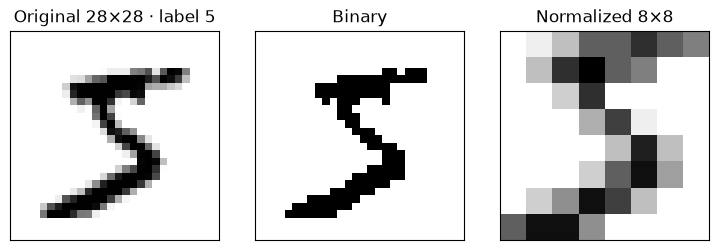

In [3]:
def show_before_after(index: int) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    axes[0].imshow(raw_train[index], cmap='gray_r', vmin=0, vmax=255)
    axes[0].set_title(f'Original 28×28 · label {y_train[index]}')
    threshold = max(1.0, float(raw_train[index].max()) * 0.5)
    binary = np.where(raw_train[index] >= threshold, 255, 0)
    axes[1].imshow(binary, cmap='gray_r', vmin=0, vmax=255)
    axes[1].set_title('Binary')
    axes[2].imshow(X_train_pixels[index].reshape(8, 8), cmap='gray_r', vmin=0, vmax=16)
    axes[2].set_title('Normalized 8×8')
    for axis in axes:
        axis.set_xticks([])
        axis.set_yticks([])
    plt.tight_layout()

show_before_after(0)

## 2. Cấu hình model

Có thể sửa cell này rồi chạy lại các cell train. Hai MLP 4 neuron dùng để minh họa mạng nhỏ; `compact_tuned` dùng mạng có đủ năng lực hơn. Tất cả ANN đều tắt early stopping.

In [4]:
MODEL_CONFIGS = {
    'logistic': {
        'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000,
    },
    'mlp_4_one_layer': {
        'hidden_layer_sizes': (4,), 'activation': 'tanh',
        'learning_rate_init': 0.001, 'max_iter': 350, 'early_stopping': False,
    },
    'mlp_4_two_layers': {
        'hidden_layer_sizes': (4, 4), 'activation': 'tanh',
        'learning_rate_init': 0.001, 'max_iter': 350, 'early_stopping': False,
    },
    'compact_tuned': {
        'hidden_layer_sizes': (48,), 'activation': 'relu',
        'learning_rate_init': 0.002, 'max_iter': 350, 'early_stopping': False,
    },
}

for name, config in MODEL_CONFIGS.items():
    print(name, config)

logistic {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000}
mlp_4_one_layer {'hidden_layer_sizes': (4,), 'activation': 'tanh', 'learning_rate_init': 0.001, 'max_iter': 350, 'early_stopping': False}
mlp_4_two_layers {'hidden_layer_sizes': (4, 4), 'activation': 'tanh', 'learning_rate_init': 0.001, 'max_iter': 350, 'early_stopping': False}
compact_tuned {'hidden_layer_sizes': (48,), 'activation': 'relu', 'learning_rate_init': 0.002, 'max_iter': 350, 'early_stopping': False}


## 3. Train bốn model

Cell dưới đây train trên toàn bộ `X_fit`. Nếu muốn thử architecture khác, sửa `MODEL_CONFIGS` rồi chạy lại cell.

In [5]:
models = {}

config = MODEL_CONFIGS['logistic']
models['logistic'] = LogisticRegression(
    C=config['C'], solver=config['solver'], max_iter=config['max_iter'], random_state=RANDOM_SEED, verbose=1
).fit(X_fit, y_fit)

for model_id in ('mlp_4_one_layer', 'mlp_4_two_layers', 'compact_tuned'):
    config = MODEL_CONFIGS[model_id]
    models[model_id] = build_mlp(
        config['hidden_layer_sizes'], config['activation'],
        config['learning_rate_init'], config['max_iter'], verbose=True
    ).fit(X_fit, y_fit)

print('trained:', list(models))

Iteration 1, loss = 1.63034528
Iteration 2, loss = 1.00889944
Iteration 3, loss = 0.85408603
Iteration 4, loss = 0.77993744
Iteration 5, loss = 0.73052746
Iteration 6, loss = 0.69979883
Iteration 7, loss = 0.68096207
Iteration 8, loss = 0.66828717
Iteration 9, loss = 0.65876997
Iteration 10, loss = 0.65242736
Iteration 11, loss = 0.64680992
Iteration 12, loss = 0.64160231
Iteration 13, loss = 0.63787037
Iteration 14, loss = 0.63390118
Iteration 15, loss = 0.62998030
Iteration 16, loss = 0.62696697
Iteration 17, loss = 0.62421158
Iteration 18, loss = 0.62233691
Iteration 19, loss = 0.61991807
Iteration 20, loss = 0.61762716
Iteration 21, loss = 0.61594914
Iteration 22, loss = 0.61464652
Iteration 23, loss = 0.61321644
Iteration 24, loss = 0.61196329
Iteration 25, loss = 0.61074618
Iteration 26, loss = 0.60961129
Iteration 27, loss = 0.60868943
Iteration 28, loss = 0.60777229
Iteration 29, loss = 0.60721731
Iteration 30, loss = 0.60656310
Iteration 31, loss = 0.60590442
Iteration 32, los

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 1.14192533
Iteration 3, loss = 0.91501807
Iteration 4, loss = 0.83307342
Iteration 5, loss = 0.78184880
Iteration 6, loss = 0.73884923
Iteration 7, loss = 0.71047304
Iteration 8, loss = 0.69063752
Iteration 9, loss = 0.67818466
Iteration 10, loss = 0.66828870
Iteration 11, loss = 0.66050147
Iteration 12, loss = 0.65476560
Iteration 13, loss = 0.64826080
Iteration 14, loss = 0.64179650
Iteration 15, loss = 0.63609171
Iteration 16, loss = 0.62930479
Iteration 17, loss = 0.62467327
Iteration 18, loss = 0.61931444
Iteration 19, loss = 0.61513601
Iteration 20, loss = 0.61062811
Iteration 21, loss = 0.60809847
Iteration 22, loss = 0.60398067
Iteration 23, loss = 0.60126760
Iteration 24, loss = 0.59789413
Iteration 25, loss = 0.59585050
Iteration 26, loss = 0.59358487
Iteration 27, loss = 0.59161074
Iteration 28, loss = 0.58861687
Iteration 29, loss = 0.58703610
Iteration 30, loss = 0.58451248
Iteration 31, loss = 0.58352148
Iteration 32, loss = 0.58147698
Iteration 33, lo

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.43598342
Iteration 2, loss = 0.20688217
Iteration 3, loss = 0.16669086
Iteration 4, loss = 0.14646610
Iteration 5, loss = 0.13278466
Iteration 6, loss = 0.12252948
Iteration 7, loss = 0.11538973
Iteration 8, loss = 0.10875039
Iteration 9, loss = 0.10449423
Iteration 10, loss = 0.09961939
Iteration 11, loss = 0.09663873
Iteration 12, loss = 0.09331850
Iteration 13, loss = 0.08990618
Iteration 14, loss = 0.08769872
Iteration 15, loss = 0.08541890
Iteration 16, loss = 0.08385220
Iteration 17, loss = 0.08200733
Iteration 18, loss = 0.08031571
Iteration 19, loss = 0.07765240
Iteration 20, loss = 0.07605628
Iteration 21, loss = 0.07520021
Iteration 22, loss = 0.07341176
Iteration 23, loss = 0.07224042
Iteration 24, loss = 0.07104515
Iteration 25, loss = 0.07085570
Iteration 26, loss = 0.06888907
Iteration 27, loss = 0.06771577
Iteration 28, loss = 0.06728115
Iteration 29, loss = 0.06661568
Iteration 30, loss = 0.06535727
Iteration 31, loss = 0.06582639
Iteration 32, los

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
for model_id, model in models.items():
    validation_accuracy = accuracy_score(y_validation, model.predict(X_validation))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f'{model_id:24} validation={validation_accuracy:.2%} test={test_accuracy:.2%}')

logistic                 validation=90.50% test=91.03%
mlp_4_one_layer          validation=84.42% test=84.78%
mlp_4_two_layers         validation=84.80% test=85.57%
compact_tuned            validation=95.26% test=95.06%


## 4. Quan sát prediction và confusion matrix

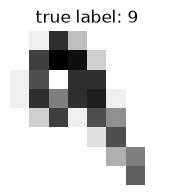

logistic → 4 52.90%
mlp_4_one_layer → 4 48.37%
mlp_4_two_layers → 4 63.92%
compact_tuned → 4 100.00%


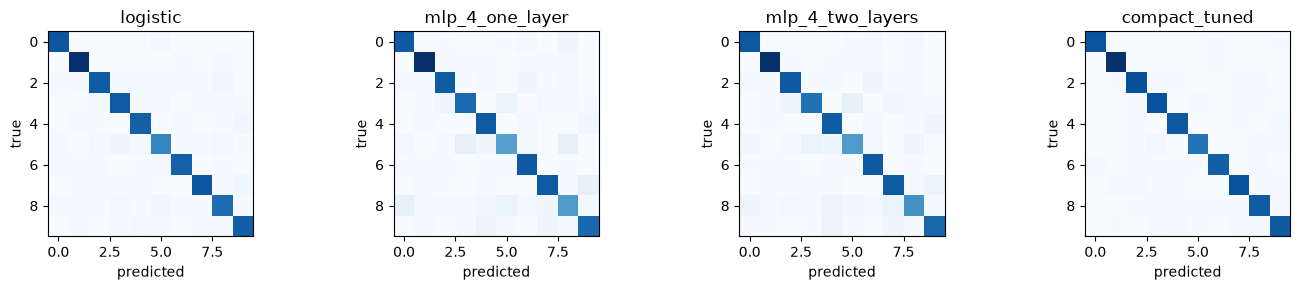

In [7]:
sample_index = 7
plt.figure(figsize=(2, 2))
plt.imshow(X_test_pixels[sample_index].reshape(8, 8), cmap='gray_r', vmin=0, vmax=16)
plt.title(f'true label: {y_test[sample_index]}')
plt.axis('off')
plt.show()

for model_id, model in models.items():
    probabilities = model.predict_proba(X_test[sample_index:sample_index + 1])[0]
    print(model_id, '→', int(np.argmax(probabilities)), f'{probabilities.max():.2%}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for axis, (model_id, model) in zip(axes, models.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test), labels=np.arange(10))
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(model_id)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')
plt.tight_layout()

## Ghi chú

Notebook này dùng để học và thử cấu hình. Muốn tạo artifact mà tab web đọc, chạy `python -m gk.web.backend.train_digits_models` để dùng đúng quy trình export production.